In [1]:
import os
os.makedirs("../results/qc",exist_ok=True)
os.makedirs("../figures/qc",exist_ok=True)
os.makedirs("../workflows",exist_ok=True)

In [2]:
import numpy as np
import scanpy as sc
import seaborn as sns
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from scipy.sparse import csc_matrix
from scipy.stats import median_abs_deviation
import anndata as ad

# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_18964\2343253169.py:14: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)


In [3]:
samples = {
    "adata_fat": r"D:\Desktop\--main\data_interim\adata_Fat_standardized.h5ad",
    "adata_spleen_marrow": r"D:\Desktop\--main\data_interim\adata_spleen_marrow_standardized.h5ad",
    "adata_heart_and_aorta": r"D:\Desktop\--main\data_interim\adata_Heart_and_Aorta_standardized.h5ad",
    "adata_kidney": r"D:\Desktop\--main\data_interim\adata_Kidney_standardized.h5ad",
    "adata_liver": r"D:\Desktop\--main\data_interim\adata_Liver_standardized.h5ad",
    "adata_lung": r"D:\Desktop\--main\data_interim\adata_Lung_standardized.h5ad",
}
adatas = {}
for sample_id, path in samples.items():
    sample_adata = sc.read_h5ad(path)       # 注意：h5ad 用 read_h5ad
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata_raw = adata.copy()

sample
adata_lung               18334
adata_spleen_marrow       7784
adata_heart_and_aorta     6138
adata_fat                 3368
adata_liver               3260
adata_kidney              1729
Name: count, dtype: int64


In [4]:
# 保留原始counts
adata.layers["counts"] = adata.X.copy()

In [5]:
adata.var_names_make_unique()

In [6]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = (adata.var_names.str.startswith("mt-")|adata.var_names.str.startswith("Mt-")|adata.var_names.str.startswith("MT-"))
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

In [7]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, percent_top=[20], log1p=True)

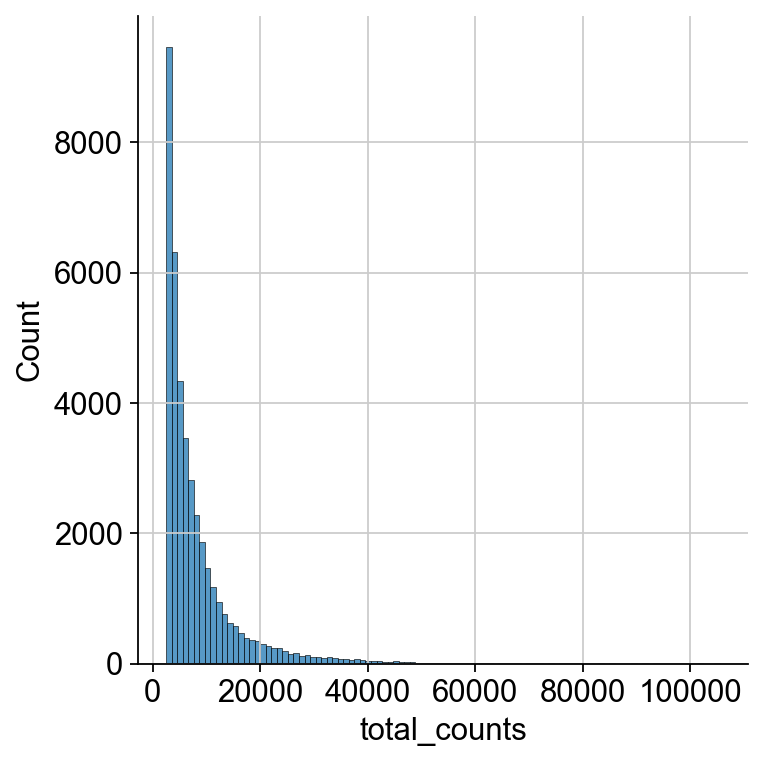

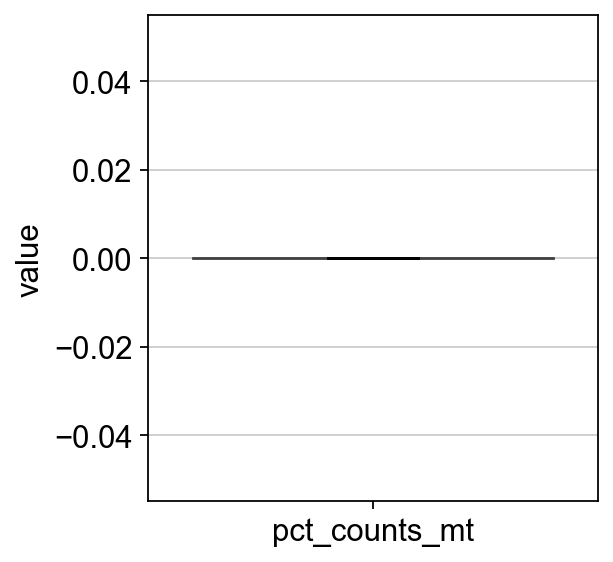

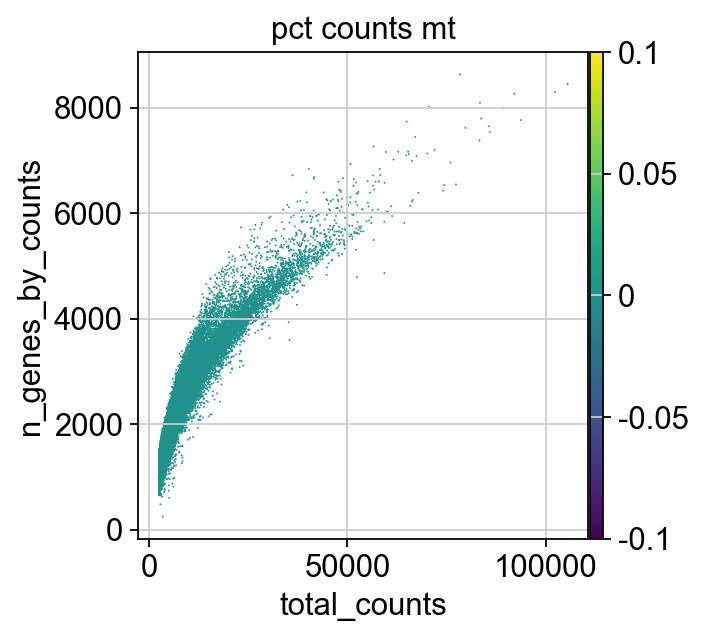

In [8]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [9]:
import pandas as pd
qc_parameters=[]

for tissue in adata.obs["tissue"].unique():
    sub = adata[adata.obs["tissue"]==tissue]

    # MAD计算
    n_gene_median = np.median(sub.obs["n_genes_by_counts"])
    n_gene_mad = median_abs_deviation(sub.obs["n_genes_by_counts"])
    lower_gene = max(200,n_gene_median-3*n_gene_mad)
    upper_gene = min(6000,n_gene_median+3*n_gene_mad)
    mt_cutoff = min(15,np.percentile(sub.obs["pct_counts_mt"],95))
    qc_parameters.append({
        "tissue":tissue,
        "n_genes_min":round(lower_gene,2),
        "n_genes_max":round(upper_gene,2),
        "pct_mt_max":round(mt_cutoff,2),
        "method":"initial n_genes 200-6000 + median+3MAD adjustment",
        "reason":"Threshold adjusted according to tissue-specific QC distribution; mitochondrial cutoff constrained by <=15%"
    })
qc_parameters=pd.DataFrame(qc_parameters)
qc_parameters.to_csv("../results/qc/qc_parameters_draft.tsv",sep="\t",index=False)

In [10]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (np.median(M) + nmads * median_abs_deviation(M) < M)
    return outlier

In [11]:
adata.obs["outlier"] = (is_outlier(adata, "log1p_total_counts", 3)
    | is_outlier(adata, "log1p_n_genes_by_counts", 3)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 3)
)
adata.obs.outlier.value_counts()

outlier
False    35028
True      5585
Name: count, dtype: int64

In [12]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (adata.obs["pct_counts_mt"] > 15)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    40613
Name: count, dtype: int64

In [13]:
audit=[]

# 初始数量
audit.append({
    "step":"raw",
    "cells_before":adata.n_obs,
    "cells_after":adata.n_obs,
    "removed":0
})

# n_genes过滤
gene_filter=(adata.obs.n_genes_by_counts>=200)&(adata.obs.n_genes_by_counts<=6000)
adata_gene=adata[gene_filter]
audit.append({
    "step":"n_genes_200_6000",
    "cells_before":adata.n_obs,
    "cells_after":adata_gene.n_obs,
    "removed":adata.n_obs-adata_gene.n_obs
})

# MAD过滤
mad_filter=~adata_gene.obs.outlier
adata_mad=adata_gene[mad_filter]
audit.append({
    "step":"median_3MAD",
    "cells_before":adata_gene.n_obs,
    "cells_after":adata_mad.n_obs,
    "removed":adata_gene.n_obs-adata_mad.n_obs
})

# mt过滤
mt_filter=~adata_mad.obs.mt_outlier
adata_final=adata_mad[mt_filter].copy()
audit.append({
    "step":"mitochondrial_filter",
    "cells_before":adata_mad.n_obs,
    "cells_after":adata_final.n_obs,
    "removed":adata_mad.n_obs-adata_final.n_obs
})
audit_df=pd.DataFrame(audit)
audit_df.to_csv("../results/qc/filtering_audit.csv",index=False)

In [14]:
age_compare=pd.DataFrame({
    "before":adata.obs.groupby("age").size(),
    "after":adata_final.obs.groupby("age").size()
})

age_compare["removed"]=(age_compare["before"]-age_compare["after"])

age_compare.to_csv("../results/qc/age_cell_change.csv")

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_18964\4167208093.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "before":adata.obs.groupby("age").size(),
C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_18964\4167208093.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "after":adata_final.obs.groupby("age").size()


In [15]:
adata.obs.columns

Index(['age', 'cell', 'cell_ontology_class', 'cell_ontology_id',
       'free_annotation', 'method', 'mouse.id', 'n_genes', 'sex', 'subtissue',
       'tissue', 'tissue_free_annotation', 'n_counts', 'louvain', 'leiden',
       'mouse_id_std', 'tissue_std', 'cell_type_original', 'age_months',
       'age_group', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'outlier', 'mt_outlier'],
      dtype='object')

In [16]:
mouse_compare=pd.DataFrame({
    "before":adata.obs.groupby("mouse.id").size(),
    "after":adata_final.obs.groupby("mouse.id").size()
})

mouse_compare["removed"]=(mouse_compare["before"]-mouse_compare["after"])

mouse_compare.to_csv("../results/qc/mouse_cell_change.csv")

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_18964\319153582.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "before":adata.obs.groupby("mouse.id").size(),
C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_18964\319153582.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "after":adata_final.obs.groupby("mouse.id").size()


In [17]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

pdf=PdfPages("../figures/qc/QC_by_tissue_mouse.pdf")

metrics=["n_genes_by_counts","total_counts","pct_counts_mt","pct_counts_ribo"]

for group in ["tissue","mouse"]:
    if group not in adata.obs.columns:
        continue
    for metric in metrics:
        plt.figure(figsize=(12,5))
        sns.violinplot(data=adata.obs,x=group,y=metric,cut=0)
        plt.xticks(rotation=90)
        plt.title(f"{metric} by {group}")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

pdf.close()

In [18]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 40613
Number of cells after filtering of low quality cells: 35028


In [28]:
adata_filtered = adata_final[:,:].copy()

# raw counts保存
adata_filtered.layers["counts"] = (adata_filtered.X.copy())

# 创建log版本
adata_log=adata_filtered.copy()

sc.pp.normalize_total(adata_log,target_sum=1e4)
sc.pp.log1p(adata_log)
adata_log.write("../data_interim/adata_log_normalized.h5ad")
adata_filtered.write("../data_interim/adata_filtered_raw.h5ad")

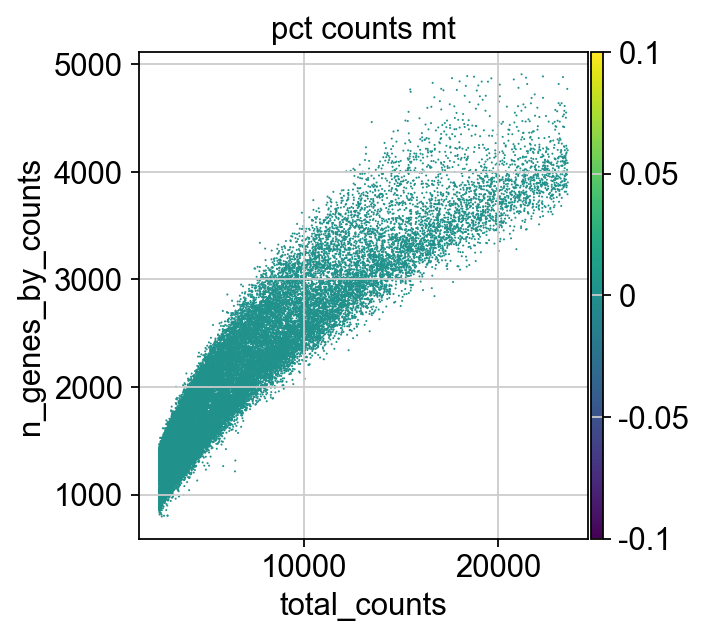

In [20]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [21]:
import logging

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

rcb.logger.setLevel(logging.ERROR)


%load_ext rpy2.ipython

In [22]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(SingleCellExperiment)
library(BiocParallel)

载入需要的程序包：SeuratObject
载入需要的程序包：sp

载入程序包：'SeuratObject'

The following objects are masked from 'package:base':

    intersect, t

载入需要的程序包：SingleCellExperiment
载入需要的程序包：SummarizedExperiment
载入需要的程序包：MatrixGenerics
载入需要的程序包：matrixStats

载入程序包：'MatrixGenerics'

The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, r

In [23]:
data_mat = adata.X.T

In [24]:
data_mat = adata.X.T.tocsc()

x = data_mat.data.astype(np.float64)
i = data_mat.indices.astype(np.int32)
p = data_mat.indptr.astype(np.int32)
dims = np.array(data_mat.shape, dtype=np.int32)

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["x"] = x
    ro.globalenv["i"] = i
    ro.globalenv["p"] = p
    ro.globalenv["dims"] = dims

In [25]:
%%R -o doublet_score -o doublet_class

x <- as.numeric(x)
i <- as.integer(i)
p <- as.integer(p)
dims <- as.integer(dims)

data_mat <- new("dgCMatrix", Dim = dims, x = x, i = i, p = p)

set.seed(123)
sce <- scDblFinder(SingleCellExperiment(list(counts = data_mat)))

doublet_score <- sce$scDblFinder.score
doublet_class <- sce$scDblFinder.class

Creating ~25000 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 5176 cells excluded from training.
iter=1, 6911 cells excluded from training.
iter=2, 6833 cells excluded from training.
Threshold found:0.167
4914 (14%) doublets called
In addition: Warning message:
In scDblFinder(SingleCellExperiment(list(counts = data_mat))) :
  You are trying to run scDblFinder on a very large number of cells. If these are from different captures, please specify this using the `samples` argument.TRUE


In [26]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    30114
doublet     4914
Name: count, dtype: int64

In [27]:
import json

workflow={
    "class":"GalaxyWorkflow",
    "name":"01_QC_scanpy_v1",
    "steps":{
        "0":{
            "type":"input",
            "name":"AnnData h5ad"
        },
        "1":{
            "type":"scanpy_calculate_qc",
            "name":"calculate n_genes total_counts mt ribo"
        },
        "2":{
            "type":"filter_cells",
            "name":"n_genes 200-6000 and mt<=15%"
        },
        "3":{
            "type":"normalize",
            "name":"log normalization"
        }
    }
}

with open("../workflows/01_qc_v1.ga","w") as f:
    json.dump(workflow,f,indent=4)